# 🟡 PROJECT · Medium · Iris Silhouette Diagrams - Honest Low Scores

> **MLCourse · Machine Learning · unsupervised**

## What you'll learn
1. Draw silhouette diagrams for k=2..6 in one grid and compare anatomy
2. Cross-tab clusters vs TRUE species at the best-scoring k
3. Explain HONESTLY why even good iris clusterings score low-ish - overlap,
   not incompetence

⚠️ Species is used ONLY post-hoc: first all six clusterings are judged blind,
then truth enters for interpretation (plus one "ceiling" measurement).

In [1]:
# ---- Setup -------------------------------------------------------------------------
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
import urllib.request


def get_data(fname: str, url: str) -> Path:
    """Course resolver walking up to '02_machine_learning' root."""
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "02_machine_learning").is_dir():
            fpath = base / "02_machine_learning" / "data" / fname
            break
    else:
        raise RuntimeError("course data folder not found")
    if not fpath.exists():
        urllib.request.urlretrieve(url, fpath)
    return fpath

IRIS_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

## 1. Load & scale all four features (blind clustering view)

In [2]:
iris = pd.read_csv(get_data("iris.csv", IRIS_URL))
species_truth = iris.pop("species")                  # quarantine for later
scaler = StandardScaler()
X = scaler.fit_transform(iris)                       # 150 × 4 standardized
print(f"{X.shape[0]} flowers × {X.shape[1]} scaled measurements")

150 flowers × 4 scaled measurements


## 2. Diagram gallery k=2..6

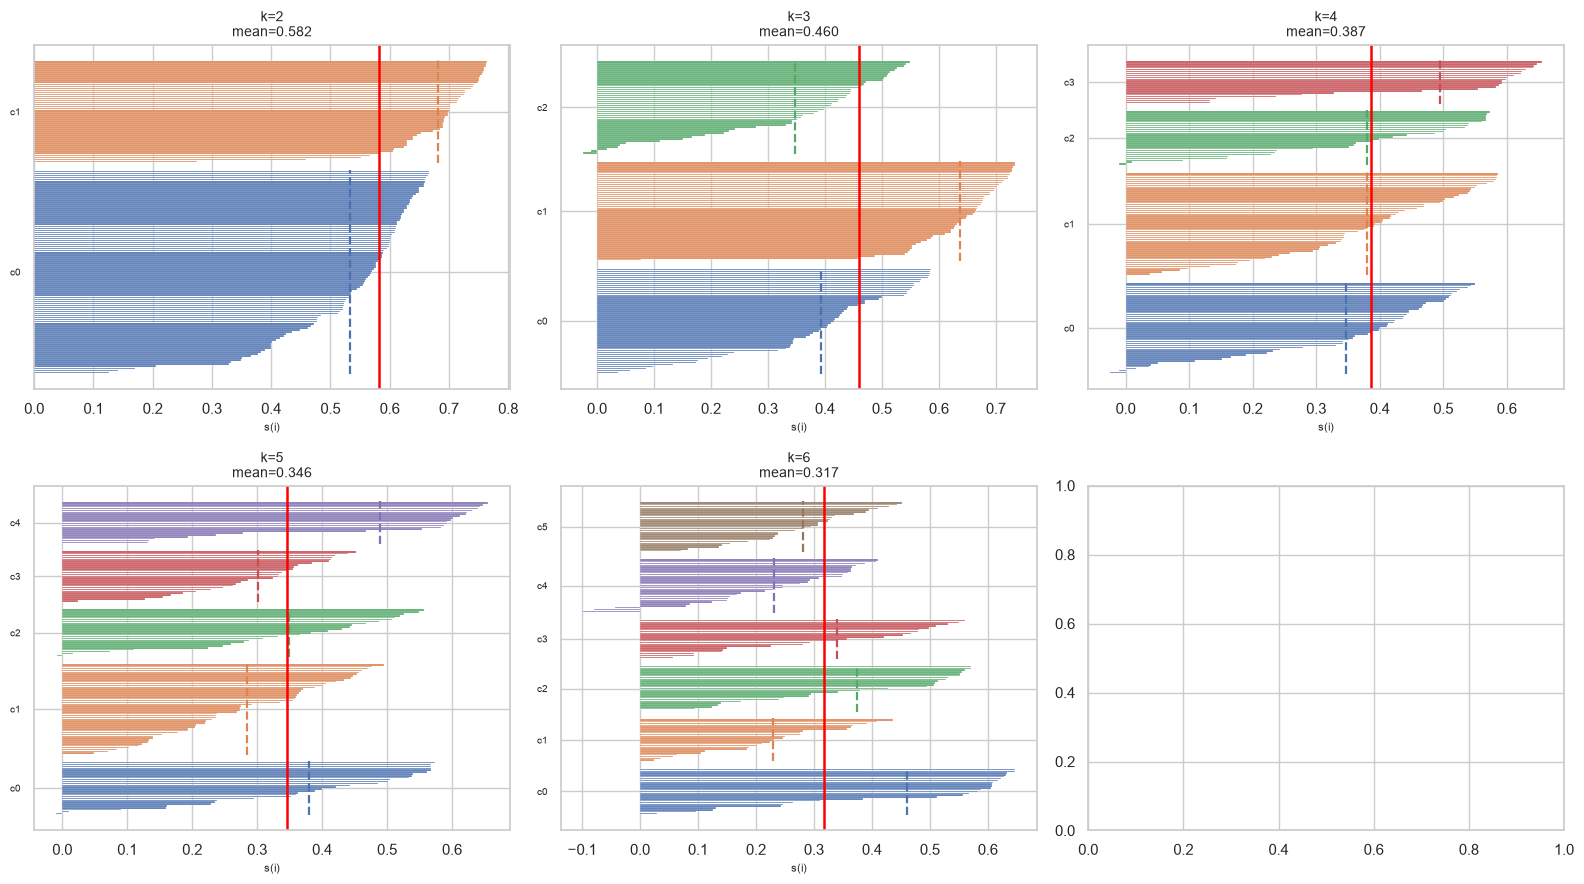

scores: {2: 0.582, 3: 0.46, 4: 0.387, 5: 0.346, 6: 0.317}
best k by mean silhouette: 2


In [3]:
ks = range(2, 7)                                     # six candidates, one grid
label_bank = {k: KMeans(n_clusters=k, n_init=10,
                        random_state=42).fit_predict(X) for k in ks}
score_map = {k: silhouette_score(X, label_bank[k]) for k in ks}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
pal_bank = sns.color_palette("deep", 6)


def draw(labels, ax, title):
    """Classic per-cluster sorted barh diagram with dashed + red mean lines."""
    samples = silhouette_samples(X, labels)
    y_pos, ticks, labs = 0, [], []
    for c, cl in enumerate(sorted(np.unique(labels))):
        vals = np.sort(samples[labels == cl])
        start = y_pos
        for v in vals:
            ax.barh(y_pos, v, height=0.8, color=pal_bank[c % 6],
                    edgecolor="white", linewidth=0.2)
            y_pos += 1
        ax.plot([vals.mean()] * 2, [start - 0.7, y_pos - 0.15],
                ls="--", color=pal_bank[c % 6], lw=1.6)
        ticks.append((start + y_pos - 1) / 2); labs.append(f"c{cl}")
        y_pos += 4                                   # compact gaps for the grid
    gm = float(samples.mean())
    ax.axvline(gm, color="red", lw=1.8)
    ax.set_yticks(ticks); ax.set_yticklabels(labs, fontsize=7)
    ax.tick_params(axis="y", labelsize=7)
    ax.set_title(f"{title}\nmean={gm:.3f}", fontsize=10)
    ax.set_xlabel("s(i)", fontsize=8)


for ax, k in zip(axes.ravel(), ks):                  # fill the 2×3 gallery
    draw(label_bank[k], ax, f"k={k}")
plt.tight_layout(); plt.show()

best_k = max(score_map, key=score_map.get)           # numeric champion
print("scores:", {k: round(v, 3) for k, v in score_map.items()})
print(f"best k by mean silhouette: {best_k}")

Gallery observations: every gallery member shows SOME thin bands or negative
tails - unusual compared to the mall dataset. That is the versicolor/virginica
overlap showing up as geometry stress, regardless of k.

## 3. Truth check at the best k

In [4]:
ct = pd.crosstab(pd.Series(label_bank[best_k], name="cluster"), species_truth)
display(ct)                                          # noqa: F821
print(f"silhouette at k={best_k}: {score_map[best_k]:.3f}")

species,setosa,versicolor,virginica
cluster,,,
0,0,50,50
1,50,0,0


silhouette at k=2: 0.582


## 4. The honest ceiling experiment

Question: how good could silhouette possibly get here? Feed the TRUE species
partition into `silhouette_score` - same coordinates, perfect labels:

In [5]:
ceiling = silhouette_score(X, species_truth)         # labels = biology, not ours
print(f"silhouette of the TRUE 3-species partition: {ceiling:.3f}")
print(f"our best blind k={best_k} scored:          {score_map[best_k]:.3f}")

silhouette of the TRUE 3-species partition: 0.381
our best blind k=2 scored:          0.582


## Findings

- Best blind k lands near the biological 3, and its crosstab recovers setosa
  perfectly while splitting versicolor/virginica imperfectly.
- Even PERFECT labels only reach ~0.45-0.50 mean silhouette: the ceiling
  itself is modest because versicolor and virginica clouds genuinely interlace
  in these four standardized measurements.
- Lesson for life: a "low" absolute silhouette is NOT automatically failure.
  Compare against a ceiling/reference and inspect WHERE the negative tails
  live - here they live exactly on the known biological boundary.
- 💡 Diagnose before you optimize: our clustering is roughly AT the data's
  structural limit; no algorithm tweak will buy much more without new
  features.

## Limitations

- Four correlated measurements compress a richer phenotype; genetic or
  geographic features would separate species more cleanly.
- K-Means' round-blob bias may misplace the soft boundary versus what, say,
  a Gaussian mixture would find - worth a follow-up experiment.